In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pk
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

Preprocessing

In [3]:
data = pd.read_csv('data/games_details_preprocessed.csv')

In [4]:
## dropping rows with NAs
data = data[data['PLUS_MINUS'].isna() == False]

In [5]:
## standardizing the data
scaler = StandardScaler()
data_standard_scaled = scaler.fit_transform(data.iloc[:, 1:])

In [6]:
data_standard_scaled = pd.DataFrame(data_standard_scaled, columns = data.columns[1:])

<Axes: >

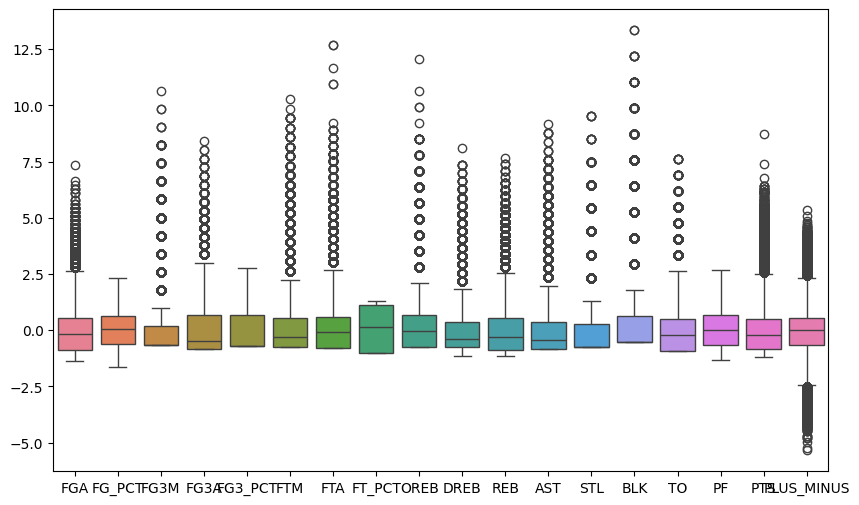

In [7]:
## plotting the boxplot of data
plt.figure(figsize=(10, 6))
sns.boxplot(data=data_standard_scaled)


In [8]:
## splitting data
y = data['PLUS_MINUS']
x = data.drop('PLUS_MINUS', axis = 1)
y_standard_scaled = data_standard_scaled['PLUS_MINUS']
x_standard_scaled = data_standard_scaled.drop('PLUS_MINUS', axis = 1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
x_standard_scaled_train, x_standard_scaled_test, y_standard_scaled_train, y_standard_scaled_test = train_test_split(x_standard_scaled, y_standard_scaled, test_size = 0.2, random_state = 42)

In [21]:
## seed = 42
## size of data to use for training
np.random.seed(42)
train_size = int(1 * len(x_standard_scaled_train))
indices = np.random.choice(x_standard_scaled_train.index, train_size, replace=False)
x_standard_scaled_train_sample = x_standard_scaled_train.loc[indices]
y_standard_scaled_train_sample = y_standard_scaled_train.loc[indices]

## sample for random_forest and svm
np.random.seed(42)
train_size_lower = int(0.1 * len(x_standard_scaled_train))
indices_lower = np.random.choice(x_standard_scaled_train.index, train_size_lower, replace=False)
x_standard_scaled_train_sample_lower = x_standard_scaled_train.loc[indices_lower]
y_standard_scaled_train_sample_lower = y_standard_scaled_train.loc[indices_lower]


In [22]:
len(x_standard_scaled_train_sample), len(x_standard_scaled_train_sample_lower)

(428221, 42822)

Model Training

In [ ]:
## dummy regressor
from sklearn.dummy import DummyRegressor

start = time.time()
dummy_reg = DummyRegressor(strategy = 'mean')
scores = cross_val_score(dummy_reg, x_standard_scaled_train_sample, y_standard_scaled_train_sample, scoring = 'neg_mean_squared_error', cv = 10)
dummy_reg_mse_scores = np.sqrt(-scores)
end = time.time()
dummy_time = end - start

## linear regression
from sklearn.linear_model import LinearRegression

start = time.time()
lin_reg = LinearRegression()
scores = cross_val_score(lin_reg, x_standard_scaled_train_sample, y_standard_scaled_train_sample, scoring = 'neg_mean_squared_error', cv = 10)
lin_reg_mse_scores = np.sqrt(-scores)
end = time.time()
lin_time = end - start

## decision tree
from sklearn.tree import DecisionTreeRegressor

start = time.time()
dt_reg = DecisionTreeRegressor()
scores = cross_val_score(dt_reg, x_standard_scaled_train_sample, y_standard_scaled_train_sample, scoring = 'neg_mean_squared_error', cv = 10)
dt_reg_mse_scores = np.sqrt(-scores)
end = time.time()
dt_time = end - start

## svm
from sklearn.svm import SVR

start = time.time()
svm_reg = SVR()
scores = cross_val_score(svm_reg, x_standard_scaled_train_sample_lower, y_standard_scaled_train_sample_lower, scoring = 'neg_mean_squared_error', cv = 10)
svm_reg_mse_scores = np.sqrt(-scores)
end = time.time()
svm_time = end - start

## random forest
from sklearn.ensemble import RandomForestRegressor

start = time.time()
rf_reg = RandomForestRegressor(n_jobs=-1)
scores = cross_val_score(rf_reg, x_standard_scaled_train_sample, y_standard_scaled_train_sample, scoring = 'neg_mean_squared_error', cv = 10)
rf_reg_mse_scores = np.sqrt(-scores)
end = time.time()
rf_time = end - start

## knn
from sklearn.neighbors import KNeighborsRegressor

start = time.time()
knn_reg = KNeighborsRegressor()
scores = cross_val_score(knn_reg, x_standard_scaled_train_sample, y_standard_scaled_train_sample, scoring = 'neg_mean_squared_error', cv = 10)
knn_reg_mse_scores = np.sqrt(-scores)
end = time.time()  
knn_time = end - start  

## adding to results
results = pd.DataFrame({'Model': ['Dummy Regressor', 'Linear Regression', 'Decision Tree', 'SVM', 'Random Forest', 'KNN'], 'MSE_mean': [np.mean(dummy_reg_mse_scores), np.mean(lin_reg_mse_scores), np.mean(dt_reg_mse_scores), np.mean(svm_reg_mse_scores), np.mean(rf_reg_mse_scores), np.mean(knn_reg_mse_scores)], 'MSE_std': [np.std(dummy_reg_mse_scores), np.std(lin_reg_mse_scores), np.std(dt_reg_mse_scores), np.std(svm_reg_mse_scores), np.std(rf_reg_mse_scores), np.std(knn_reg_mse_scores)]})




In [62]:
## svm
from sklearn.svm import SVR

start = time.time()
svm_reg = SVR(C = 10, epsilon = 1.0, gamma = 0.001, kernel = 'rbf')
scores = cross_val_score(svm_reg, x_standard_scaled_train_sample_lower, y_standard_scaled_train_sample_lower, scoring = 'neg_mean_squared_error', cv = 10)
svm_reg_mse_scores = np.sqrt(-scores)
end = time.time()
svm_time = end - start

In [82]:
svm_reg.get_params()

{'C': 10,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'epsilon': 1.0,
 'gamma': 0.001,
 'kernel': 'rbf',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

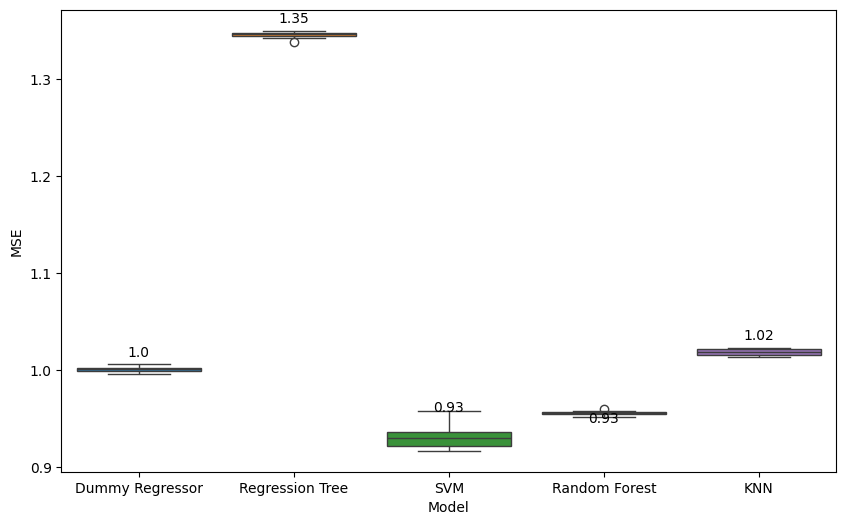

In [80]:
## plotting data
plt.figure(figsize = (10, 6))
sns.boxplot(data = [dummy_reg_mse_scores, dt_reg_mse_scores, svm_reg_mse_scores, rf_reg_mse_scores, knn_reg_mse_scores])
plt.xticks(range(5), ['Dummy Regressor', 'Regression Tree', 'SVM', 'Random Forest', 'KNN'])
#axes
plt.xlabel('Model')
plt.ylabel('MSE')
## writing the mean over each boxplot but SVM
for i in range(5):
    if i != 2:
        plt.text(i, results['MSE_mean'][i] + 0.013, str(round(results['MSE_mean'][i], 2)), ha = 'center')
    else:
        plt.text(i, results['MSE_mean'][i] + 0.025, str(round(results['MSE_mean'][i], 2)), ha = 'center')
plt.show()

In [81]:
results

,Model,MSE_mean,MSE_std
0,Dummy Regressor,1.000597,0.002717
1,Decision Tree,1.345207,0.003442
2,SVM,0.932061,0.013856
3,Random Forest Optimized,0.932762,0.003237
4,KNN,1.018251,0.003383


In [79]:
time = pd.DataFrame({'Model': ['Dummy Regressor', 'Linear Regression', 'Decision Tree', 'SVM', 'Random Forest', 'KNN'], 'Time': [dummy_time, lin_time, dt_time, svm_time, rf_time, knn_time]})

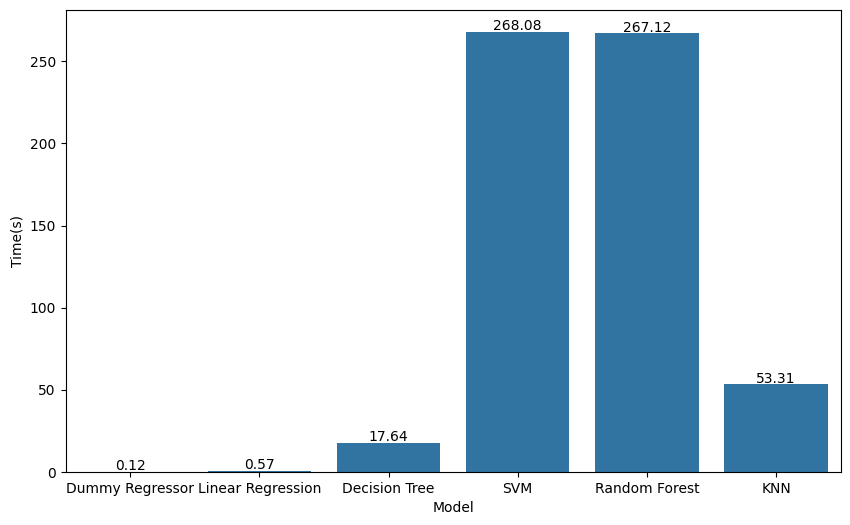

In [43]:
## plotting time
plt.figure(figsize = (10, 6))
sns.barplot(x = 'Model', y = 'Time', data = time)
plt.xlabel('Model')
plt.ylabel('Time(s)')
## plotting the legend with the time
for i in range(6):
    plt.text(i, time['Time'][i] + 1, str(round(time['Time'][i], 2)), ha = 'center')
plt.show()

In [45]:
## display parameters used in rf
rf_reg.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [49]:
## Optimising the Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 30, 50],
    'ccp_alpha': [0.0, 0.1, 0.5]
}

rf_reg_optim = RandomForestRegressor(n_jobs=-1, random_state=42)

In [51]:
import time
start = time.time()
grid_search = GridSearchCV(estimator = rf_reg_optim, param_grid = param_grid, cv = 3, n_jobs = -1, verbose = 2, scoring='neg_mean_squared_error')
grid_search.fit(x_standard_scaled_train_sample_lower, y_standard_scaled_train_sample_lower)
end = time.time()
rf_optim_time = end - start

Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ......ccp_alpha=0.0, max_depth=10, n_estimators=100; total time=   5.4s
[CV] END ......ccp_alpha=0.0, max_depth=10, n_estimators=100; total time=   5.6s
[CV] END ......ccp_alpha=0.0, max_depth=10, n_estimators=100; total time=   5.7s
[CV] END ......ccp_alpha=0.0, max_depth=10, n_estimators=300; total time=  16.7s
[CV] END ......ccp_alpha=0.0, max_depth=10, n_estimators=300; total time=  16.9s
[CV] END ......ccp_alpha=0.0, max_depth=10, n_estimators=300; total time=  17.0s
[CV] END ......ccp_alpha=0.0, max_depth=30, n_estimators=100; total time=  11.5s
[CV] END ......ccp_alpha=0.0, max_depth=30, n_estimators=100; total time=  11.8s
[CV] END ......ccp_alpha=0.0, max_depth=10, n_estimators=500; total time=  28.2s
[CV] END ......ccp_alpha=0.0, max_depth=10, n_estimators=500; total time=  28.3s
[CV] END ......ccp_alpha=0.0, max_depth=30, n_estimators=100; total time=  11.8s
[CV] END ......ccp_alpha=0.0, max_depth=10, n_es

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END ......ccp_alpha=0.0, max_depth=30, n_estimators=500; total time=  56.4s
[CV] END ......ccp_alpha=0.0, max_depth=50, n_estimators=300; total time=  32.1s
[CV] END ......ccp_alpha=0.0, max_depth=30, n_estimators=500; total time=  55.0s
[CV] END ......ccp_alpha=0.0, max_depth=30, n_estimators=500; total time=  55.4s
[CV] END ......ccp_alpha=0.0, max_depth=50, n_estimators=300; total time=  31.1s
[CV] END ......ccp_alpha=0.0, max_depth=50, n_estimators=300; total time=  30.2s
[CV] END ......ccp_alpha=0.1, max_depth=10, n_estimators=100; total time=   4.1s
[CV] END ......ccp_alpha=0.1, max_depth=10, n_estimators=100; total time=   5.8s
[CV] END ......ccp_alpha=0.1, max_depth=10, n_estimators=100; total time=   6.0s
[CV] END ......ccp_alpha=0.1, max_depth=10, n_estimators=300; total time=  17.7s
[CV] END ......ccp_alpha=0.1, max_depth=10, n_estimators=300; total time=  17.9s
[CV] END ......ccp_alpha=0.1, max_depth=10, n_estimators=300; total time=  18.2s
[CV] END ......ccp_alpha=0.0

In [52]:
## best parameters
grid_search.best_params_

{'ccp_alpha': 0.0, 'max_depth': 10, 'n_estimators': 500}

In [53]:
## retraining the model with the best parameters
start = time.time()
rf_optimized = RandomForestRegressor(n_estimators = 500, max_depth = 10, n_jobs=-1, random_state=42)
scores_optimized = cross_val_score(rf_optimized, x_standard_scaled_train_sample, y_standard_scaled_train_sample, scoring = 'neg_mean_squared_error', cv = 10)
rf_optimized_mse_scores = np.sqrt(-scores_optimized)
end = time.time()
rf_optimized_time = end - start

In [75]:
## adding to results
results = pd.DataFrame({'Model': ['Dummy Regressor', 'Decision Tree', 'SVM', 'Random Forest Optimized', 'KNN'], 'MSE_mean': [np.mean(dummy_reg_mse_scores), np.mean(dt_reg_mse_scores), np.mean(svm_reg_mse_scores), np.mean(rf_optimized_mse_scores), np.mean(knn_reg_mse_scores)], 'MSE_std': [np.std(dummy_reg_mse_scores), np.std(dt_reg_mse_scores), np.std(svm_reg_mse_scores), np.std(rf_optimized_mse_scores), np.std(knn_reg_mse_scores)]})

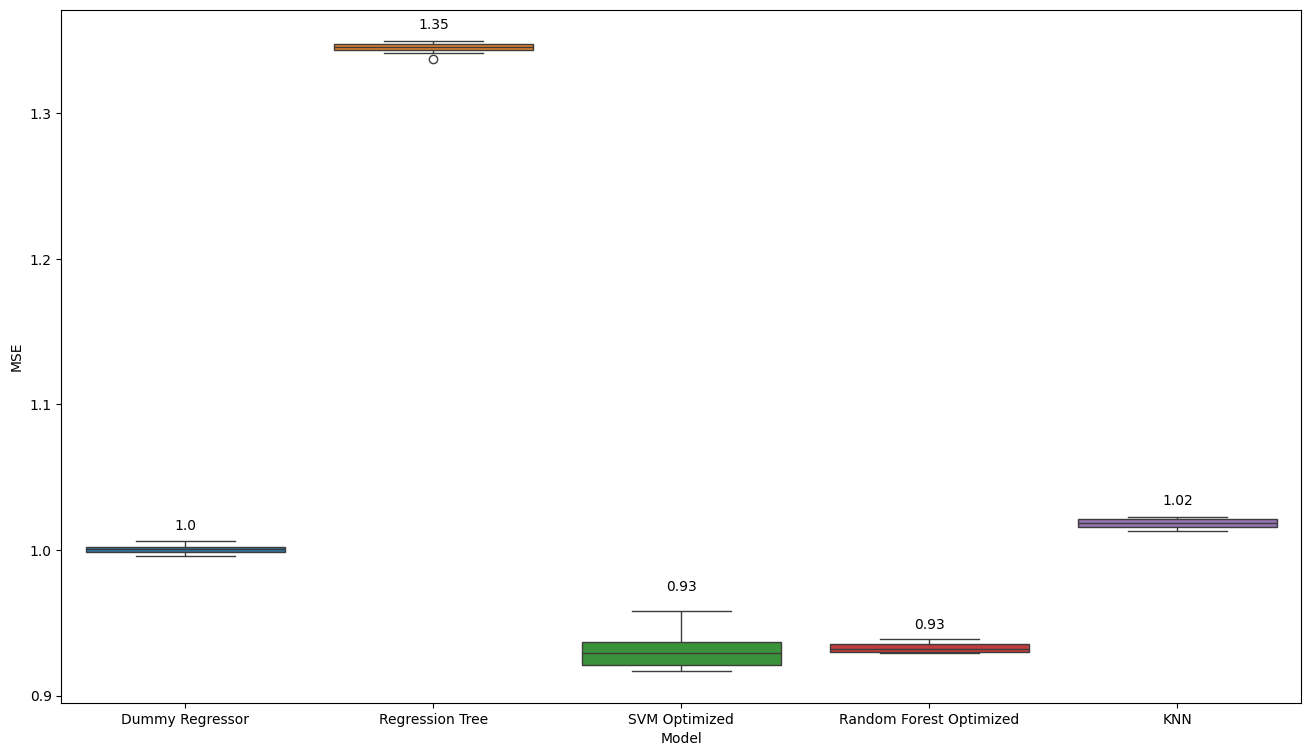

In [77]:
## plotting data
plt.figure(figsize = (16, 9))
sns.boxplot(data = [dummy_reg_mse_scores, dt_reg_mse_scores, svm_reg_mse_scores, rf_optimized_mse_scores, knn_reg_mse_scores])
plt.xticks(range(5), ['Dummy Regressor',  'Regression Tree', 'SVM Optimized', 'Random Forest Optimized', 'KNN'])
#axes
plt.xlabel('Model')
plt.ylabel('MSE')
## writing the mean over each boxplot but SVM
for i in range(5):
    if i != 2:
        plt.text(i, results['MSE_mean'][i] + 0.013, str(round(results['MSE_mean'][i], 2)), ha = 'center')
    else:
        plt.text(i, results['MSE_mean'][i] + 0.04, str(round(results['MSE_mean'][i], 2)), ha = 'center')
plt.show()

In [71]:
## training svm with multiple sizes of the training data
sizes = [0.0001, 0.001, 0.01, 0.025]
for size in sizes:
    np.random.seed(42)
    train_size = int(size * len(x_standard_scaled_train))
    indices = np.random.choice(x_standard_scaled_train.index, train_size, replace=False)
    x_standard_scaled_train_sample = x_standard_scaled_train.loc[indices]
    y_standard_scaled_train_sample = y_standard_scaled_train.loc[indices]

    start = time.time()
    svm_reg = SVR(C = 10, epsilon = 1.0, gamma = 0.001, kernel = 'rbf')
    scores = cross_val_score(svm_reg, x_standard_scaled_train_sample, y_standard_scaled_train_sample, scoring = 'neg_mean_squared_error', cv = 10)
    svm_reg_mse_scores = np.sqrt(-scores)
    end = time.time()
    print('Size: ', size, 'Time: ', end - start, 'MSE: ', np.mean(svm_reg_mse_scores))

Size:  0.0001 Time:  0.016448974609375 MSE:  0.9802353449104663
Size:  0.001 Time:  0.02058696746826172 MSE:  0.9572968815434308
Size:  0.01 Time:  0.8105888366699219 MSE:  0.9380573203112654
Size:  0.025 Time:  4.281407833099365 MSE:  0.9320605784602956


In [72]:
for size in sizes:
    train_size = int(size * len(x_standard_scaled_train))
    indices = np.random.choice(x_standard_scaled_train.index, train_size, replace=False)
    x_standard_scaled_train_sample = x_standard_scaled_train.loc[indices]
    print('Size: ', size, 'Number of samples: ', len(x_standard_scaled_train_sample))

Size:  0.0001 Number of samples:  42
Size:  0.001 Number of samples:  428
Size:  0.01 Number of samples:  4282
Size:  0.025 Number of samples:  10705


In [73]:
(0.9380573203112654-0.9320605784602956)/0.9320605784602956

0.006433854182392428